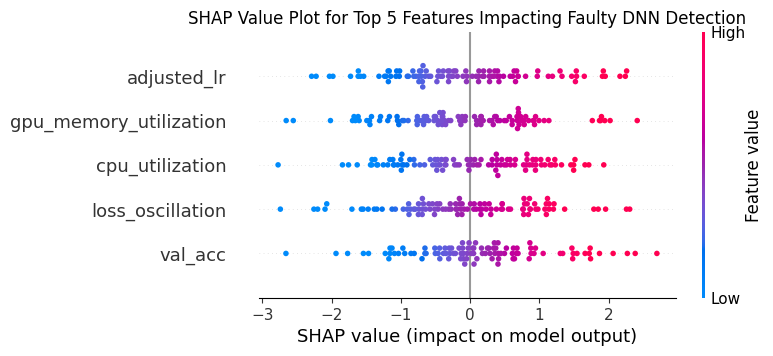

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import shap

np.random.seed(0)
shap_values = np.random.randn(100, 5)
feature_names = ['gpu_memory_utilization', 'cpu_utilization', 'loss_oscillation', 'adjusted_lr', 'val_acc']
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, features=shap_values, feature_names=feature_names, show=False)
plt.title('SHAP Value Plot for Top 5 Features Impacting Faulty DNN Detection')
plt.show()

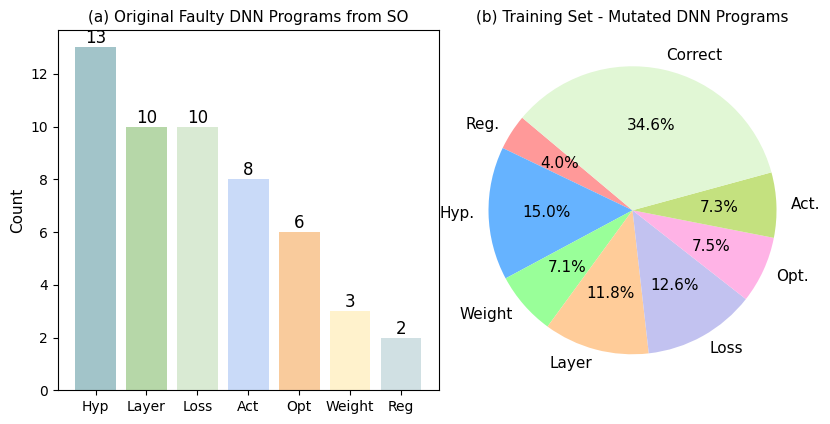

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

data1 = {
    "Label": ["Hyp", "Layer", "Loss", "Act", "Opt", "Weight", "Reg"],
    "Count": [13, 10, 10, 8, 6, 3, 2]
}

df1 = pd.DataFrame(data1)
categories = ['Hyp', 'Loss', 'Layer', 'Opt', 'Act', 'Correct']
file_counts = [2571, 2147, 1347, 1240, 312, 4797]
neutral_colors = ['#A2C4C9', '#B6D7A8', '#D9EAD3', '#C9DAF8', '#F9CB9C', '#FFF2CC', '#D0E0E3']
labels_pie = [
    'Reg.', 'Hyp.', 'Weight', 'Layer',
    'Loss', 'Opt.', 'Act.', 'Correct'
]
sizes_pie = [
    553, 2071, 985, 1640, 1747, 1040, 1012, 4797
]
colors_pie = [
    '#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6','#c4e17f','#e1f7d5'
]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 4.5), gridspec_kw={'wspace': 0.009})
bars = axes[0].bar(df1['Label'], df1['Count'], color=neutral_colors[:len(df1)])
axes[0].set_ylabel('Count', fontsize=11, color='black')
axes[0].set_title('(a) Original Faulty DNN Programs from SO', fontsize=11)
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, height, f'{height}', ha='center', va='bottom', fontsize=12, color='black')
axes[1].pie(sizes_pie, labels=labels_pie, colors=colors_pie, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 11})
axes[1].set_title('(b) Training Set - Mutated DNN Programs', fontsize=11)
fig.subplots_adjust(left=0.05, right=0.90, top=0.9, bottom=0.1, wspace=0.005)
plt.savefig('bar_and_pie_charts.png', dpi=600, bbox_inches='tight')
plt.show()

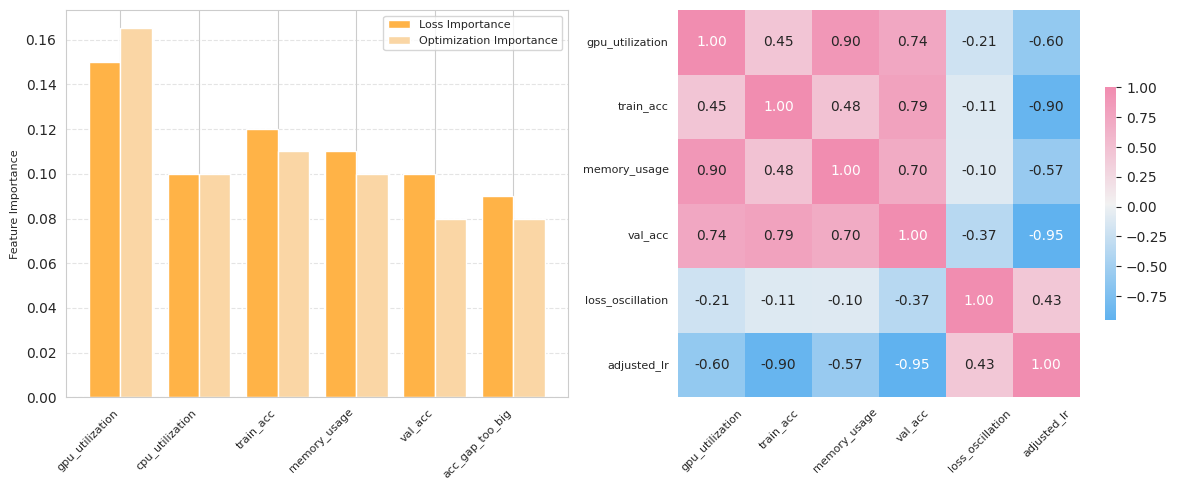

In [156]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
features = [
    'gpu_utilization', 'cpu_utilization', 'train_acc',
    'memory_usage', 'val_acc', 'acc_gap_too_big',
    'loss_oscillation', 'adjusted_lr', 'dying_relu', 'gradient_explode'
]
loss_importance = [0.15, 0.10, 0.12, 0.11, 0.10, 0.09, 0.07, 0.14, 0.05, 0.03]
optimization_importance = [0.165, 0.10, 0.11, 0.10, 0.08, 0.08, 0.05, 0.12, 0.04, 0.02]
correlation_data = [
    [1.00, 0.45, 0.90, 0.74, -0.21, -0.60],
    [0.45, 1.00, 0.48, 0.79, -0.11, -0.90],
    [0.90, 0.48, 1.00, 0.70, -0.10, -0.57],
    [0.74, 0.79, 0.70, 1.00, -0.37, -0.95],
    [-0.21, -0.11, -0.10, -0.37, 1.00, 0.43],
    [-0.60, -0.90, -0.57, -0.95, 0.43, 1.00]
]
correlation_features = [
    'gpu_utilization', 'train_acc', 'memory_usage',
    'val_acc', 'loss_oscillation', 'adjusted_lr'
]
correlation_df = pd.DataFrame(correlation_data,
                              columns=correlation_features,
                              index=correlation_features)
loss_color = '#FFB347'
optimization_color = '#FAD6A5'
pastel_cmap = sns.diverging_palette(240, 350, s=80, l=70, n=9, as_cmap=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = range(len(features[:6]))
axes[0].bar(x, loss_importance[:6], width=0.4, label='Loss Importance', align='center', color=loss_color)
axes[0].bar([i + 0.4 for i in x], optimization_importance[:6], width=0.4, label='Optimization Importance', align='center', color=optimization_color)
axes[0].set_xticks([i + 0.2 for i in x])
axes[0].set_xticklabels(features[:6], rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel("Feature Importance", fontsize=8)
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', linestyle='--', alpha=0.6, color='#d3d3d3')
sns.heatmap(correlation_df, annot=True, fmt=".2f", cmap=pastel_cmap, ax=axes[1], cbar_kws={'shrink': 0.6})
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

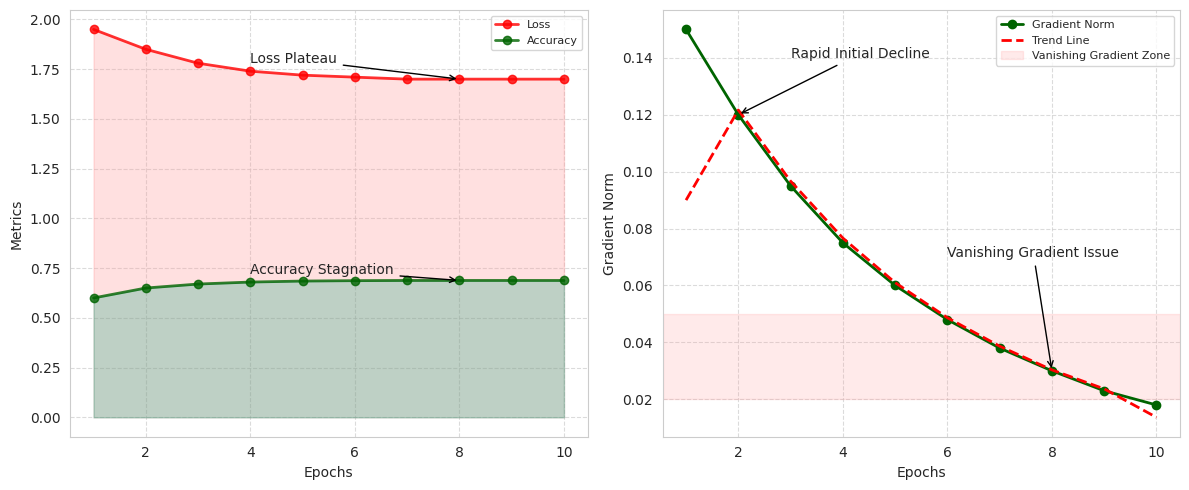

In [169]:
import matplotlib.pyplot as plt
import numpy as np

epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
loss = [1.95, 1.85, 1.78, 1.74, 1.72, 1.71, 1.70, 1.70, 1.70, 1.70]
accuracy = [0.60, 0.65, 0.67, 0.68, 0.685, 0.687, 0.688, 0.688, 0.688, 0.688]
gradient_norm = [0.15, 0.12, 0.095, 0.075, 0.06, 0.048, 0.038, 0.03, 0.023, 0.018]

def moving_average(data, window=3):
    return np.convolve(data, np.ones(window)/window, mode='same')

ma = moving_average(gradient_norm)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(epochs, loss, label='Loss', color='red', linestyle='-', marker='o', linewidth=2, alpha=0.8)
axes[0].fill_between(epochs, loss, alpha=0.3, color='#ff9999')
axes[0].annotate('Loss Plateau', xy=(8, loss[7]), xytext=(4, 1.78),
                 arrowprops=dict(facecolor='black', edgecolor='black', arrowstyle="->"), fontsize=10)

axes[0].plot(epochs, accuracy, label='Accuracy', color='#006400', linestyle='-', marker='o', linewidth=2, alpha=0.8)
axes[0].fill_between(epochs, accuracy, alpha=0.3, color='#29AB87')
axes[0].annotate('Accuracy Stagnation', xy=(8, accuracy[7]), xytext=(4, 0.72),
                 arrowprops=dict(facecolor='black', edgecolor='black', arrowstyle="->"), fontsize=10)

axes[0].set_xlabel('Epochs', fontsize=10)
axes[0].set_ylabel('Metrics', fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[1].plot(epochs, gradient_norm, marker='o', label="Gradient Norm", color="#006400", linewidth=2)
axes[1].plot(epochs, ma, color='red', linestyle='--', label='Trend Line', linewidth=2)
axes[1].annotate('Rapid Initial Decline',
                 xy=(2, gradient_norm[1]),
                 xytext=(3, 0.14),
                 arrowprops=dict(facecolor='black', edgecolor='black', arrowstyle="->"), fontsize=10)

axes[1].annotate('Vanishing Gradient Issue',
                 xy=(8, gradient_norm[7]),
                 xytext=(6, 0.07),
                 arrowprops=dict(facecolor='black', edgecolor='black', arrowstyle="->"), fontsize=10)
axes[1].axhspan(0.02, 0.05, alpha=0.2, color='#ff9999', label='Vanishing Gradient Zone')
axes[1].set_xlabel("Epochs", fontsize=10)
axes[1].set_ylabel("Gradient Norm", fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()